In [16]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from torch.utils.data import DataLoader
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import pandas as pd
import os
import matplotlib.pyplot as plt

In [21]:

# 1. 데이터 로딩
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # FFT 용으로 흑백 변환
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# 2. FFT + 3. Spectrum 계산
def compute_alpha(img):
    img = img.squeeze(0).numpy()  # [1,H,W] -> [H,W]
    F = np.fft.fftshift(np.fft.fft2(img))
    P = np.abs(F)**2
    
    # 4. Radial frequency axis
    h, w = P.shape
    y, x = np.indices((h, w))
    cx, cy = w//2, h//2
    r = np.sqrt((x - cx)**2 + (y - cy)**2).flatten()
    P = P.flatten()
    
    # 5. log-log plot
    valid = (r > 0) & (P > 1e-8)
    log_r = np.log(r[valid]).reshape(-1, 1)
    log_P = np.log(P[valid])
    
    # 6. Linear regression
    reg = LinearRegression().fit(log_r, log_P)
    alpha = -reg.coef_[0]  # 주의! 부호 반전
    
    return alpha


In [22]:
alphas = []

for idx, (img, _) in tqdm(enumerate(dataloader), total=len(dataloader)):
    alpha = compute_alpha(img[0])
    alphas.append({'id': idx, 'alpha': alpha})

df = pd.DataFrame(alphas)


100%|██████████| 50000/50000 [00:17<00:00, 2939.72it/s]


,id,alpha
0,0,3.722726
1,1,3.779818
2,2,4.357288
3,3,3.337301
4,4,4.092270
...,...,...
49995,49995,3.867908
49996,49996,3.492083
49997,49997,4.131788
49998,49998,3.691927


In [26]:
# 7. 저장
os.makedirs('./fft_alpha', exist_ok=True)
df.to_csv('./fft_alpha/alpha_values.csv', index=False)

print("✅ Alpha 추정 완료! 데이터 수:", len(df))


✅ Alpha 추정 완료! 데이터 수: 50000


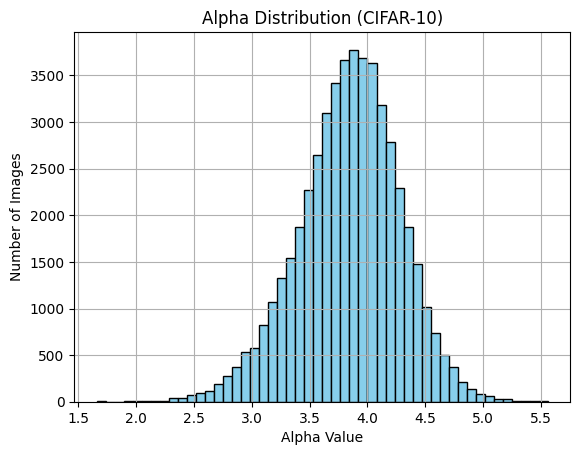

In [27]:
# Load your alpha file
df = pd.read_csv('./fft_alpha/alpha_values.csv')

# Plot
plt.hist(df['alpha'], bins=50, color='skyblue', edgecolor='black')
plt.title('Alpha Distribution (CIFAR-10)')
plt.xlabel('Alpha Value')
plt.ylabel('Number of Images')
plt.grid(True)
plt.show()
